In [39]:
!pip install pandas plotly matplotlib seaborn nbformat scikit-learn  pyarrow==14.0.2 --upgrade --quiet

  error: subprocess-exited-with-error
  
  × Building wheel for pyarrow (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [358 lines of output]
      <string>:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
      C:\Users\DELL\AppData\Local\Temp\pip-build-env-233yla10\overlay\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\DELL\AppData\Local\Temp\pip-build-env-233yla10\overlay\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\DELL\AppData\Local\Temp\pip-build-env-233yla10\overlay\Lib\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License classifiers are 

In [40]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn import preprocessing
from urllib.request import urlretrieve
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
%matplotlib inline

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

**Reading values from Parquet**

In [41]:
train_inputs=pd.read_parquet('train_inputs.parquet')
val_inputs=pd.read_parquet('val_inputs.parquet')
test_inputs=pd.read_parquet('test_inputs.parquet')

X_train=pd.read_parquet('X_train.parquet')
X_val=pd.read_parquet('X_val.parquet')
X_test=pd.read_parquet('X_test.parquet')

train_targets=pd.read_parquet('train_targets.parquet')['RainTomorrow']
val_targets=pd.read_parquet('val_targets.parquet')['RainTomorrow']
test_targets=pd.read_parquet('test_targets.parquet')['RainTomorrow']

In [42]:
print('train_inputs: ',train_inputs.shape)
print('train_targets: ',train_targets.shape)
print('X_train: ',X_train.shape)
print('val_inputs: ',val_inputs.shape)
print('val_targets: ',val_targets.shape)
print('X_val: ',X_val.shape)
print('test_inputs: ',test_inputs.shape)
print('test_targets: ',test_targets.shape)
print('Xtest.shape: ',X_test.shape)

train_inputs:  (98988, 124)
train_targets:  (98988,)
X_train:  (98988, 119)
val_inputs:  (17231, 124)
val_targets:  (17231,)
X_val:  (17231, 119)
test_inputs:  (25974, 124)
test_targets:  (25974,)
Xtest.shape:  (25974, 119)


**Training and Visualization of Decision Tree**

In [43]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)

In [44]:
model.fit(X_train,train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
train_preds=model.predict(X_train)
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(98988,), dtype=object)

In [46]:
pd.value_counts(train_preds)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


No     76707
Yes    22281
Name: count, dtype: int64

In [47]:
train_probs=model.predict_proba(X_train)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(98988, 2))

In [48]:
from sklearn.metrics import accuracy_score,confusion_matrix
acc=accuracy_score(train_preds,train_targets)
acc

0.9999797955307714

Text(0.5, 1.0, 'train Confusion Matrix')

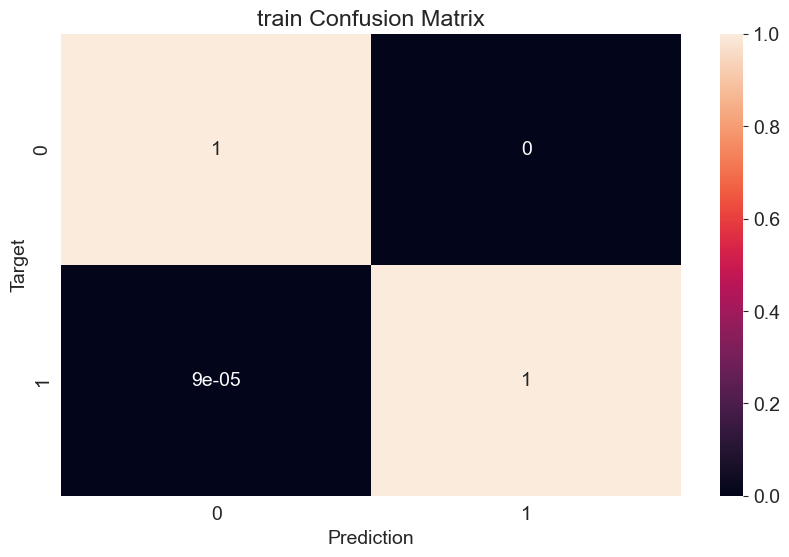

In [49]:
cf=confusion_matrix(train_targets,train_preds,normalize='true')
plt.figure()
sns.heatmap(cf,annot=True)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.title('{} Confusion Matrix'.format('train'))

**Testing Using validations and testing data**

In [50]:
val_preds=model.predict(X_val)
test_preds=model.predict(X_test)
print('accuracy of validation: ',model.score(X_val,val_targets))
print('accuracy of test: ',model.score(X_test,test_targets))

accuracy of validation:  0.7921188555510418
accuracy of test:  0.7741202741202741


In [51]:
print('train_inputs: ',train_inputs.shape)
print('train_targets: ',train_targets.shape)
print('val_inputs: ',val_inputs.shape)
print('val_targets: ',val_targets.shape)
print('test_inputs: ',test_inputs.shape)
print('test_targets: ',test_targets.shape)

train_inputs:  (98988, 124)
train_targets:  (98988,)
val_inputs:  (17231, 124)
val_targets:  (17231,)
test_inputs:  (25974, 124)
test_targets:  (25974,)


0.7921188555510418


Text(0.5, 1.0, 'validation Confusion Matrix')

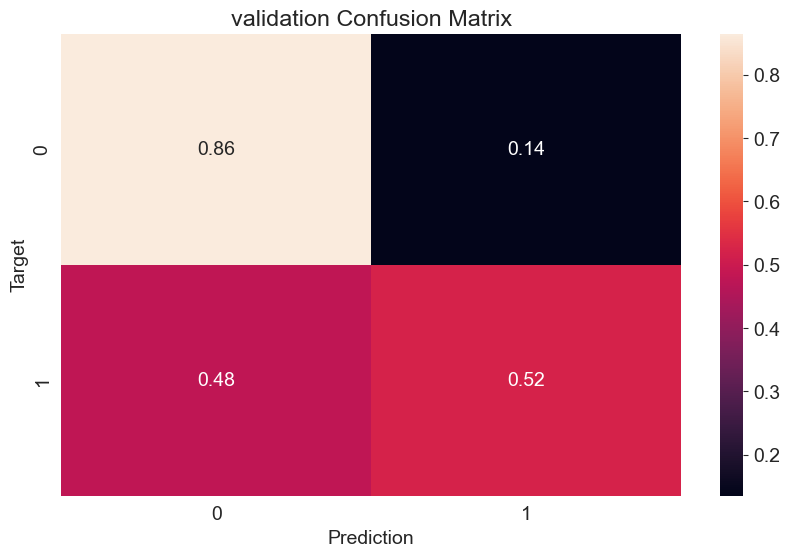

In [52]:
cf=confusion_matrix(val_targets,val_preds,normalize='true')
print(accuracy_score(val_targets,val_preds))
plt.figure()
sns.heatmap(cf,annot=True)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.title('{} Confusion Matrix'.format('validation'))

0.7741202741202741


Text(0.5, 1.0, 'test Confusion Matrix')

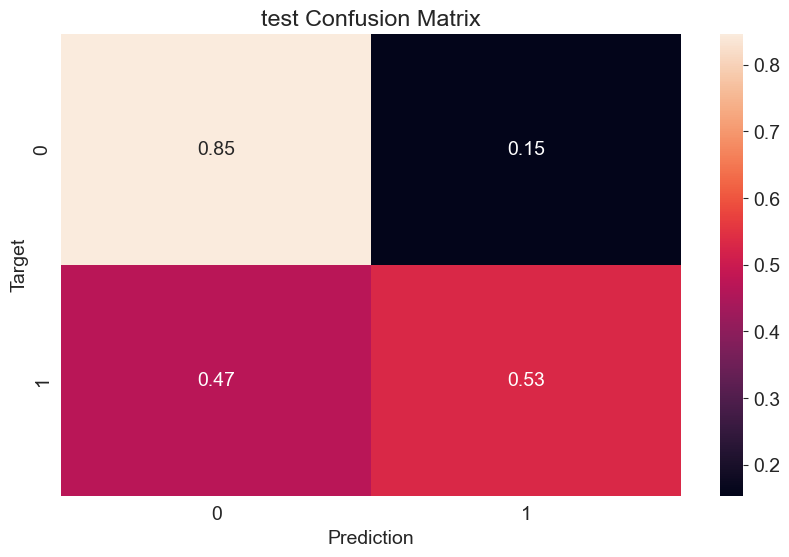

In [53]:
cf=confusion_matrix(test_targets,test_preds,normalize='true')
print(accuracy_score(test_targets,test_preds))
plt.figure()
sns.heatmap(cf,annot=True)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.title('{} Confusion Matrix'.format('test'))

**Visualize tree**

[Text(0.6769463421262046, 0.9897959183673469, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.4482657843531768, 0.9693877551020408, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.5626060632396908, 0.9795918367346939, 'True  '),
 Text(0.251409538420088, 0.9489795918367347, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.09346103055531807, 0.9285714285714286, 'Pressure3pm <= 0.583\ngini = 0.363\nsamples = 12620\nvalue = [9618, 3002]'),
 Text(0.03925424925639855, 0.9081632653061225, 'WindGustSpeed <= 0.364\ngini = 0.469\nsamples = 4691\nvalue = [2932, 1759]'),
 Text(0.00890738341751912, 0.8877551020408163, 'Humidity3pm <= 0.275\ngini = 0.435\nsamples = 3251\nvalue = [2210, 1041]'),
 Text(0.002313360307800374, 0.8673469387755102, 'WindDir9am_NE <= 0.5\ngini = 0.161\nsamples = 272\nvalue = [248, 24]'),
 Text(0.0014947866604248573, 0.8469387755102041, 'Location_Watsonia <

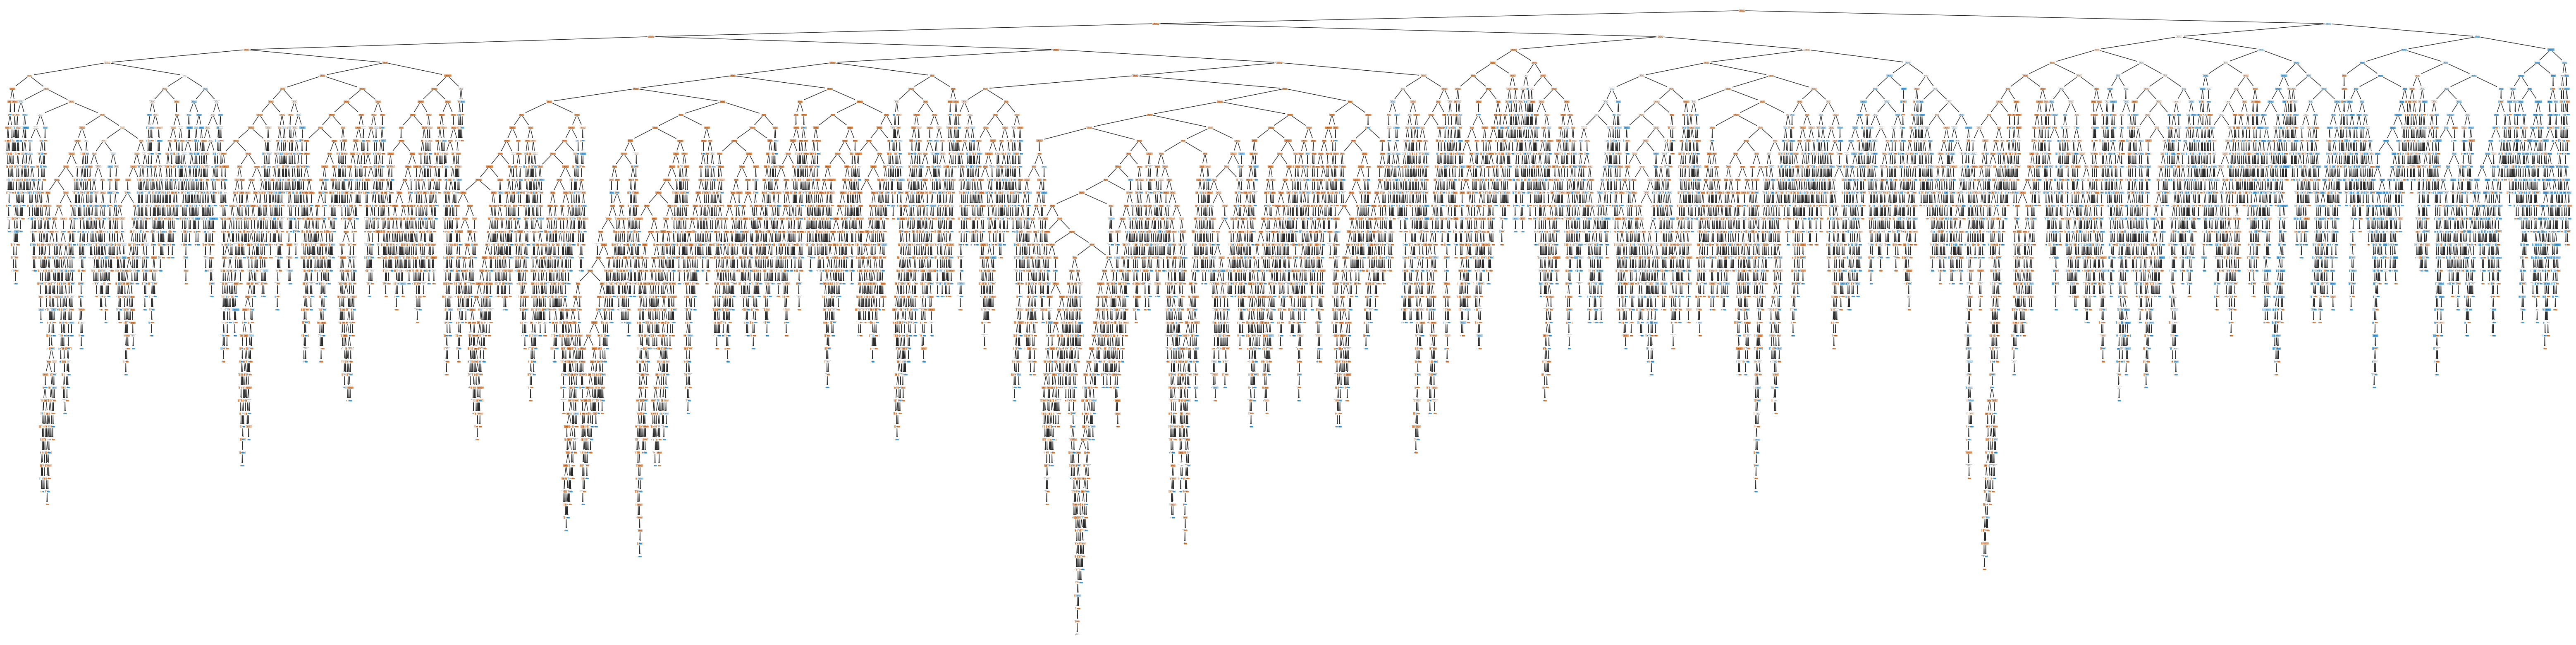

In [55]:
from sklearn.tree import plot_tree,export_text
plt.figure(figsize=(80,20))
plot_tree(model,feature_names=X_train.columns,max_depth=4,filled=True)

In [56]:
model.tree_.max_depth

48

In [ ]:
tree_test=export_text(model,max_depth=10,feature_names=list(X_train.columns))
print(tree_test[:5000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated